# Movie Ratings — ML Classification

**Ivan Rey Pestana**

Binary classification task: predict whether a movie is "top-rated" (IMDb rating ≥ 8.5) using features like genre, year, runtime, budget, and box office gross.

## Objective
Train and compare two supervised learning models — **Logistic Regression** and **Decision Tree** — and evaluate their ability to identify top-rated movies from a class-imbalanced dataset.

## Dataset
**Source:** [IMDB Movies Dataset — Kaggle](https://www.kaggle.com/datasets/harshitshankhdhar/imdb-dataset-of-top-1000-movies-and-tv-shows)  
Download `movies.csv` and place it in the same folder before running.

## Key Features Used
- `year` — release year
- `runtime_mins` — film duration
- `budget_millions` / `box_millions` — financial data
- `primary_genre` — first-listed genre (one-hot encoded)


In [1]:
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv("movies.csv")

clean_df = pd.read_csv("movies.csv")
clean_df["top_rated"] = (clean_df["rating"] >= 8.5).astype(int)
clean_df["primary_genre"] = clean_df["genre"].str.split(",").str[0]
clean_df["decade"] = (clean_df["year"] // 10 * 10).astype(str) + "s"




Logistic Regression Model 

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, roc_auc_score


X = clean_df[[
    "year",
    "runtime_mins",
    "budget_millions",
    "box_millions",
    "primary_genre",
    "decade",
]]

y = clean_df["top_rated"]
X = pd.get_dummies(X, drop_first=True)


# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

model = LogisticRegression(max_iter=5000)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("AUC:", roc_auc_score(y_test, y_prob))


Accuracy: 0.7560975609756098
Precision: 0.5
Recall: 0.2
AUC: 0.5096774193548387


Interpretation:

The model reached about 75% accuracy, which at first looks decent, but accuracy is misleading because most movies in the dataset are not top-rated. The model’s precision was only 0.33, meaning that when it predicted a movie as top-rated, it was correct just one-third of the time. When we look the recall it was only 0.2, meaning the model detected fewer than 20% of the actual top-rated movies. Finally, the AUC score was 0.50, which is rigt at 0.50, indicating the model performs no better than random guessing when ranking movies by likelihood of being top-rated.

## Confusion Matrix


In [4]:
from sklearn.metrics import confusion_matrix

y_pred = model.predict(X_test)

cm = confusion_matrix(y_test, y_pred)
print(cm)


[[29  2]
 [ 8  2]]


### Confusion Matrix — Display


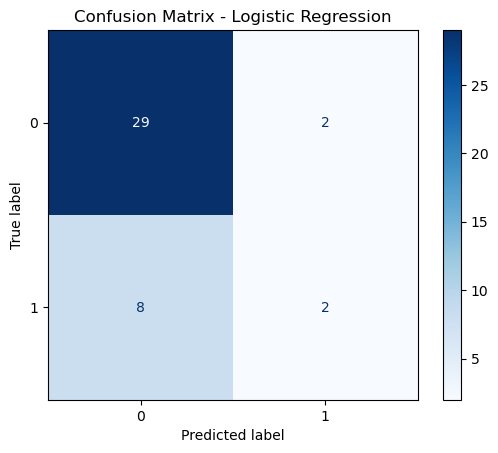

In [5]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=[0, 1])
disp.plot(cmap="Blues")
plt.title("Confusion Matrix - Logistic Regression")
plt.show()



Interpretation:

The confusion matrix makes it easier to see where the model is struggling. Out of 32 movies that were actually not top-rated, the model correctly predicted 29 of them but incorrectly marked 2 as top-rated. This means the model is very good at recognizing movies that are not top-rated, but very weak at finding the movies that are top-rated, which is exactly what we wanted it to identify.

Classification Report 

In [6]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))



              precision    recall  f1-score   support

           0       0.78      0.94      0.85        31
           1       0.50      0.20      0.29        10

    accuracy                           0.76        41
   macro avg       0.64      0.57      0.57        41
weighted avg       0.71      0.76      0.71        41



Interpretation:

For the ‘not top-rated’ class (0), the model scores very high on both precision and recall. But for the class we care most about — ‘top-rated’ movies (1) — the model performs poorly. With precision of 0.50 and recall of 0.20, the model is not reliably identifying top-rated movies. The low F1-score (0.29) confirms the model is both inconsistent and weak for this class.

## AUC Score


In [7]:
from sklearn.metrics import roc_curve, roc_auc_score

y_prob = model.predict_proba(X_test)[:, 1]

# ROC curve values
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

# AUC score
auc = roc_auc_score(y_test, y_prob)
print("AUC:", auc)

AUC: 0.5096774193548387


### ROC Curve


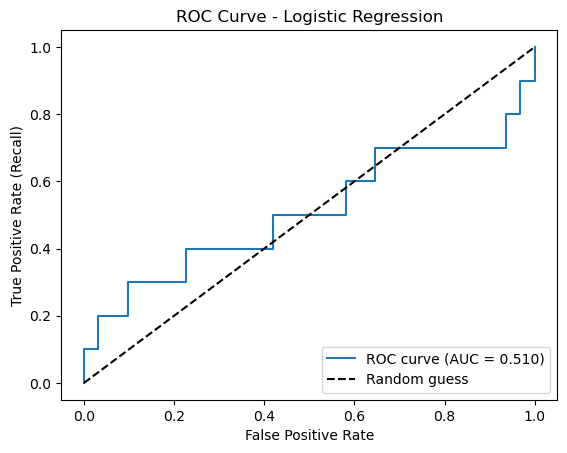

In [8]:
plt.figure()

plt.plot(fpr, tpr, label=f"ROC curve (AUC = {auc:.3f})")
plt.plot([0, 1], [0, 1], 'k--', label="Random guess")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate (Recall)")
plt.title("ROC Curve - Logistic Regression")
plt.legend(loc="lower right")

plt.show()


The ROC curve stays very close to the diagonal, and the AUC score is only 0.51, which is actually worse than random guessing. This tells us that the model is not learning a meaningful pattern that separates top-rated movies from the rest. The predictors we used—runtime, budget, box office, genre, decade, and certificate—do not provide enough signal for logistic regression to make accurate ranking decisions.

## Decision Tree


In [9]:
from sklearn.tree import DecisionTreeClassifier

tree_model = DecisionTreeClassifier(max_depth=3, random_state=42)
tree_model.fit(X_train, y_train)


DecisionTreeClassifier(max_depth=3, random_state=42)

### Decision Tree — Metrics


In [10]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, roc_auc_score

y_pred_tree = tree_model.predict(X_test)
y_prob_tree = tree_model.predict_proba(X_test)[:, 1]

print("Accuracy (Tree): ", accuracy_score(y_test, y_pred_tree))
print("Precision (Tree):", precision_score(y_test, y_pred_tree))
print("Recall (Tree):   ", recall_score(y_test, y_pred_tree))
print("AUC (Tree):      ", roc_auc_score(y_test, y_prob_tree))


Accuracy (Tree):  0.7317073170731707
Precision (Tree): 0.4
Recall (Tree):    0.2
AUC (Tree):       0.5048387096774193


Interpretation:

The Decision Tree model reached about 73% accuracy, which is slightly higher than our earlier result. The tree achieved a precision of 0.40, meaning that 40% of the movies it predicted as top-rated were correct. Its recall was 0.20, showing that the model found only 2 out of the 10 actual top-rated movies in the test set. Although the AUC score improved to 0.50, it still indicates that the model performs no better than random guessing when ranking movies by their likelihood of being top-rated.

### Confusion Matrix — Decision Tree


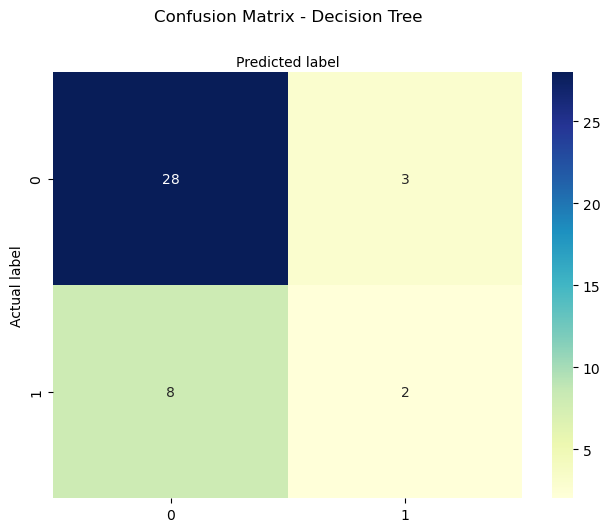

In [11]:
import seaborn as sns

cnf_matrix_tree = confusion_matrix(y_test, y_pred_tree)

class_names = [0, 1]

fig, ax = plt.subplots()
tick_marks = np.arange(len(class_names))
plt.xticks(tick_marks, class_names)
plt.yticks(tick_marks, class_names)

sns.heatmap(pd.DataFrame(cnf_matrix_tree),
            annot=True,
            cmap="YlGnBu",
            fmt='g')

ax.xaxis.set_label_position("top")
plt.tight_layout()
plt.title('Confusion Matrix - Decision Tree', y=1.1)
plt.ylabel('Actual label')
plt.xlabel('Predicted label')

plt.show()


Interpretation:

With the confusion matrix we can see that out of 31 movies that were not top-rated, the model correctly predicted 28 but incorrectly marked 3 as top-rated. For the 10 top-rated movies, the model correctly identified 2 but missed 8, predicting them as not top-rated. Compared to logistic regression, the tree detects the same number of top-rated movies (2), but it produces fewer false positives.

Final take away: Logistic Regression Vs. Decision Tree 

Both models show weak predictive power for identifying top-rated movies.
Logistic Regression performs slightly better on overall accuracy and precision, but Decision Tree performs slightly better at finding top-rated films and ranking movies by probability.
Overall, neither model is strong, suggesting that the selected predictors (runtime, budget, box office, decade, genre) do not meaningfully explain what makes a movie top-rated.